In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#signed binary to signed decimal

def todecimal(x, bits):
    assert len(x) <= bits
    n = int(x,2)
    s = 1 << (bits-1)
    return (n&s - 1) - (n&s)

In [3]:
#Compute binary representative of filter coeffecients

#Number of coeffecients
tap = 8
#For computing first scale, we want to represent filter coeffecients as 8-bit numbers
N1 = 8
#this is used to convert the filter inputs to 16-bit signed values
N2 = 16
#this is the output bit width
N3 = 32

real_coeff = (1/tap)

In [4]:
#bit representation of the coefficients
coeff_bit = np.binary_repr(int(real_coeff*(2**(N1-1))), N1)

In [5]:
#double check
todecimal(coeff_bit, N1)/(2**(N1-1))

0.125

In [6]:
#generate a test sequence
timeVector = np.linspace(0, 2*np.pi, 100)
output = np.sin(2*timeVector) + np.cos(3*timeVector) + 0.3*np.random.randn(len(timeVector))

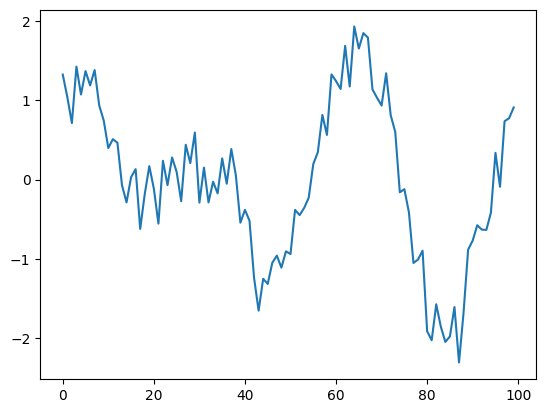

In [7]:
plt.plot(output)
plt.show()

In [8]:
#convert to integers

#this list contains the N2-bit signed representation of the sin sequence
list1 = []
for number in output:
    list1.append(np.binary_repr(int(number*(2**(N1-1))), N2))

In [9]:
#Save the converted sequence to the datafile
with open('input.data','w') as file:
    for number in list1:
        file.write(number + '\n')

In [28]:
#After, run Vivado code

In [50]:
#From here, we read the filtered values, convert them to decimal representation and plot the filtered values
read_b = []

In [51]:
#read data
with open("save.data") as file:
    for line in file:
        read_b.append(line.rstrip('\n'))

In [52]:
#This list contains the converted values
n_l = []
for by in read_b:
    n_l.append(todecimal(by, N3)/(2**(2*(N1-1))))

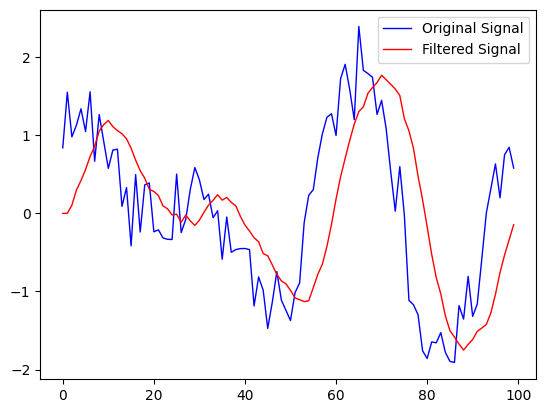

In [53]:
plt.plot(output, color='blue', linewidth=1, label='Original Signal')
plt.plot(n_l, color='red', linewidth=1, label='Filtered Signal')
plt.legend()
plt.savefig('results.png',dpi=1000)
plt.show()

In [54]:
# [17]: Calculate Golden Model and MSE
# [17]: Calculate Reference Model and Auto-Align MSE
from scipy.signal import lfilter
import numpy as np

# 1. Create the theoretical reference filter
coeffs = np.ones(8) / 8.0 
ref_output = lfilter(coeffs, 1.0, output)

# 2. Auto-Align the Signals using Cross-Correlation
hw_output = np.array(n_l)

correlation = np.correlate(hw_output, ref_output, mode='full')
delay = np.argmax(correlation) - (len(ref_output) - 1)

print(f"Auto-Detected Hardware Latency: {delay} clock cycles")

# Slice the arrays automatically based on the detected delay
if delay > 0:
    aligned_hw_output = hw_output[delay:]
    aligned_ref_output = ref_output[:len(aligned_hw_output)]
elif delay < 0: 
    aligned_ref_output = ref_output[-delay:]
    aligned_hw_output = hw_output[:len(aligned_ref_output)]
else:
    aligned_hw_output = hw_output
    aligned_ref_output = ref_output

# 3. Calculate the Mean Squared Error (MSE)
mse = np.mean((aligned_ref_output - aligned_hw_output)**2)

print(f"Mean Squared Error (MSE) vs. Reference Model: {mse:.6f}")
if mse < 0.05:
    print("Verification Passed: Hardware output matches the theoretical model.")
else:
    print("Verification Failed: Hardware output deviates from the theoretical model.")

Auto-Detected Hardware Latency: 2 clock cycles
Mean Squared Error (MSE) vs. Reference Model: 0.000007
Verification Passed: Hardware output matches the theoretical model.


In [55]:
# [18]: The Vivado Metrics Logger
import pandas as pd
import os

# --- YOU ONLY CHANGE THESE VARIABLES WHEN YOU RUN VIVADO ---
current_version = "Baseline"    
luts = 0       # Read from Report Utilization
ffs = 80        # Read from Report Utilization
dsps = 7         # Read from Report Utilization
fmax = 110.8      # Calculate from Timing Report: 1000 / (T - WNS)
static_power = 0.131   # Read from Report Power
dynamic_power = 0.042  
# -----------------------------------------------------------

metrics = {
    "Architecture": current_version,
    "LUTs": luts,
    "FFs": ffs,
    "DSPs": dsps,
    "Fmax_MHz": fmax,
    "Static_Power_W": static_power,
    "Dynamic_Power_W": dynamic_power,
    "MSE": round(mse, 6)
}

file_path = 'project_metrics.csv'
new_data = pd.DataFrame([metrics])

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    df = df[df['Architecture'] != current_version]
    df = pd.concat([df, new_data], ignore_index=True)
else:
    df = new_data

df.to_csv(file_path, index=False)
print(f"Successfully logged {current_version} metrics to {file_path}")
display(df)

Successfully logged Baseline metrics to project_metrics.csv


,Architecture,LUTs,FFs,DSPs,Fmax_MHz,Static_Power_W,Dynamic_Power_W,MSE
0,Baseline,0,80,7,110.8,0.131,0.042,0.000007


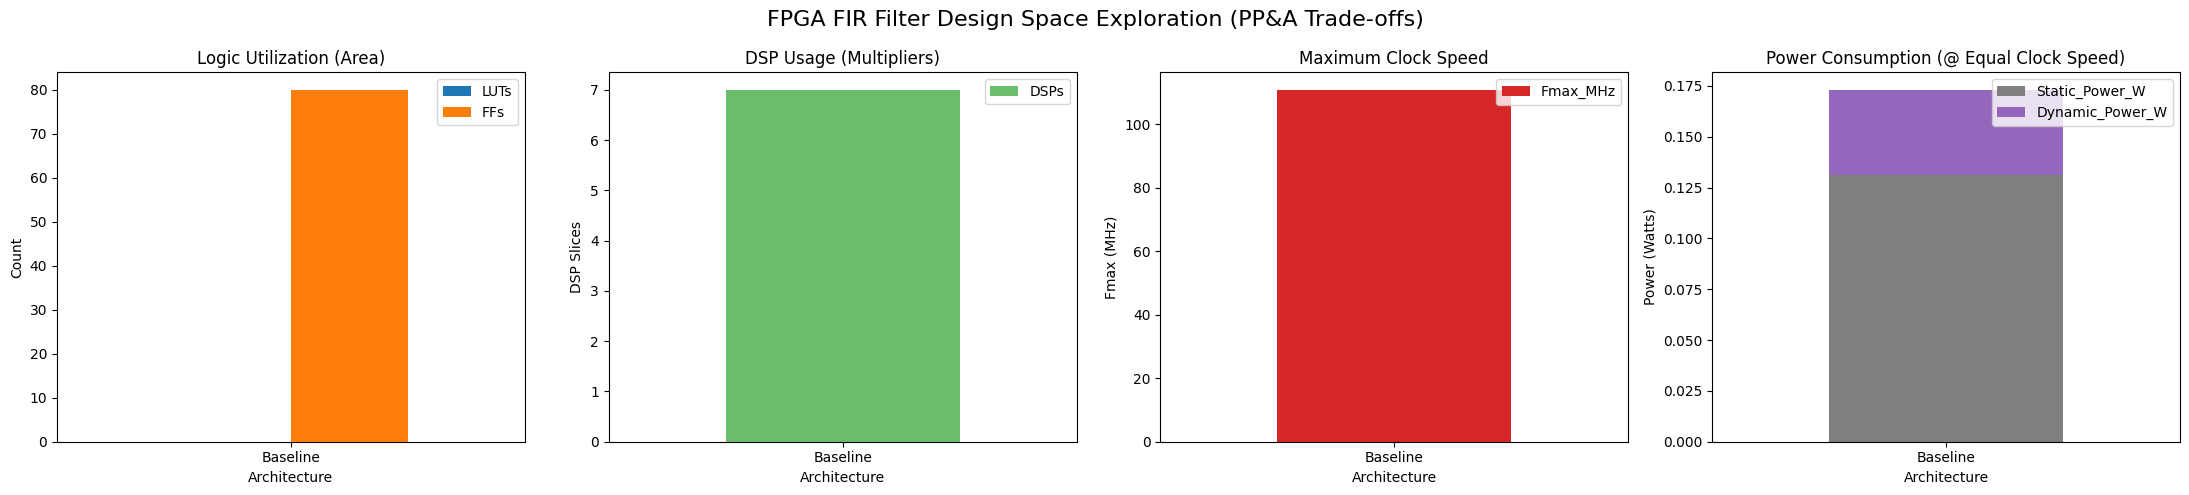

In [56]:
# [19]: Generate Hardware Trade-off Charts for Presentation
import matplotlib.pyplot as plt
import pandas as pd
import os

file_path = 'project_metrics.csv'

if os.path.exists(file_path):
    df_plot = pd.read_csv(file_path)

    # Plot 4 comparison charts (1 row, 4 columns)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle("FPGA FIR Filter Design Space Exploration (PP&A Trade-offs)", fontsize=16)

    # 1. Area
    df_plot.plot(x='Architecture', y=['LUTs', 'FFs'], kind='bar', ax=ax1, color=['#1f77b4', '#ff7f0e'])
    ax1.set_title("Logic Utilization (Area)")
    ax1.set_ylabel("Count")
    ax1.tick_params(axis='x', rotation=0)

    # 2. Multipliers
    df_plot.plot(x='Architecture', y='DSPs', kind='bar', ax=ax2, color='#2ca02c', alpha=0.7)
    ax2.set_title("DSP Usage (Multipliers)")
    ax2.set_ylabel("DSP Slices")
    ax2.tick_params(axis='x', rotation=0)

    # 3. Speed
    df_plot.plot(x='Architecture', y='Fmax_MHz', kind='bar', ax=ax3, color='#d62728')
    ax3.set_title("Maximum Clock Speed")
    ax3.set_ylabel("Fmax (MHz)")
    ax3.tick_params(axis='x', rotation=0)

    # 4. POWER (Stacked Bar Chart)
    df_plot.plot(x='Architecture', y=['Static_Power_W', 'Dynamic_Power_W'], kind='bar', stacked=True, ax=ax4, color=['#7f7f7f', '#9467bd'])
    ax4.set_title("Power Consumption (@ Equal Clock Speed)")
    ax4.set_ylabel("Power (Watts)")
    ax4.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.savefig("Hardware_Tradeoff_Charts.png", dpi=300)
    plt.show()...
else:
    print("CSV file not found. Run the logger cell [18] first!")